# Hybrid Bioprocess Lab — Interactive Analysis

This notebook replicates the full analysis of the `hybrid-bioprocess-lab` project:

1. **Run the test suite** — unit, scientific-constraint, and regression tests.
2. **Train and evaluate a hybrid model** via the Flyte training path.
3. **Run an Optuna hyperparameter sweep** and inspect the best trial.
4. **Visualise predictions** and the learned correction multiplier.

> Author: Kemal Yaylali  
> Websites: [kemal.yaylali.uk](https://kemal.yaylali.uk), [kemalyaylali.bio](https://kemalyaylali.bio)


## Setup

Add `src/` to the path so the local `hybridbio` package is importable without installing it, then import the project surface and check the feature-contract version.

In [1]:
import sys
from pathlib import Path

# Add project src/ to PYTHONPATH so the local package is importable
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

from hybridbio import (
    FEATURE_VERSION,
    FeedProfile,
    HybridModel,
    KineticParameters,
    TrainingConfig,
    evaluate,
    generate_dataset,
    train_and_evaluate,
    train_test_split_batches,
)
from hybridbio.features import FEATURE_NAMES
from hybridbio.hybrid import growth_multiplier_curve

print(f"hybridbio feature version: {FEATURE_VERSION}")
print(f"feature names ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")

hybridbio feature version: v2
feature names (7): ('S', 'L', 'Xv', 'S_over_Ks', 'L_over_Ki', 'mu_mech', 't_norm')


## 1. Test suite

Run the full pytest suite. The suite has three parts:

- `test_mechanistic.py` — ordinary unit tests on the ODE core.
- `test_scientific_constraints.py` — biological/thermodynamic admissibility tests.
- `test_regression.py` — golden values, feature-contract pins, and the hybrid-must-beat-baseline assertion.

In [2]:
import subprocess

result = subprocess.run(
    ["python", "-m", "pytest", "-v", "--tb=short"],
    cwd=project_root,
    capture_output=True,
    text=True,
)

print(result.stdout)
if result.returncode != 0:
    print("STDERR:")
    print(result.stderr)
    raise SystemExit(f"pytest failed with code {result.returncode}")

# Extract summary line for later
summary_line = next(
    (line for line in result.stdout.splitlines() if "passed" in line and "failed" in line),
    None,
)
print(f"\nSummary: {summary_line}")

============================= test session starts ==============================
platform darwin -- Python 3.14.6, pytest-9.1.1, pluggy-1.6.0
rootdir: /Users/kemal/Desktop/codes/ml/hybrid-bioprocess-lab
configfile: pyproject.toml
testpaths: tests
collected 30 items

tests/test_mechanistic.py ...........                                    [ 36%]
tests/test_regression.py .........                                       [ 66%]
tests/test_scientific_constraints.py ..........                          [100%]

============================== 30 passed in 2.63s ==============================


Summary: None


## 2. Generate data and train a hybrid correction model

Use the project's public API to generate 24 synthetic batches, split by batch, train a correction model, and evaluate both the hybrid and the mechanistic-only baseline.

In [3]:
params = KineticParameters()
cfg = TrainingConfig()

batches = generate_dataset(n_batches=24, seed=7)
train_batches, test_batches = train_test_split_batches(batches, n_test=6)

print(f"train batches: {len(train_batches)}")
print(f"test batches:  {len(test_batches)}")

hybrid, hybrid_report, baseline_report = train_and_evaluate(
    train_batches, test_batches, params, cfg
)

print("\n=== Hybrid model ===")
print(hybrid_report.render())

print("\n=== Mechanistic-only baseline ===")
print(baseline_report.render())

improvement = 100.0 * (
    1.0 - hybrid_report.metrics["nrmse_mean"] / baseline_report.metrics["nrmse_mean"]
)
print(f"\nnRMSE improvement over baseline: {improvement:+.1f}%")

train batches: 18
test batches:  6

=== Hybrid model ===
Evaluation over 6 batch(es)
----------------------------------------------
  final_titre_rel_err            0.0474
  nrmse_L                        0.0289
  nrmse_P                        0.0280
  nrmse_S                        0.1212
  nrmse_Xv                       0.0560
  nrmse_mean                     0.0586
----------------------------------------------
  scientific constraints              0 violation(s)
  verdict                          PASS

=== Mechanistic-only baseline ===
Evaluation over 6 batch(es)
----------------------------------------------
  final_titre_rel_err            0.0595
  nrmse_L                        0.0367
  nrmse_P                        0.0422
  nrmse_S                        0.1612
  nrmse_Xv                       0.0695
  nrmse_mean                     0.0774
----------------------------------------------
  scientific constraints              0 violation(s)
  verdict                          PAS

### Visualise predictions on one held-out batch

Plot observed vs predicted trajectories for the four scored states (viable cells, glucose, lactate, product titre) on the first test batch.

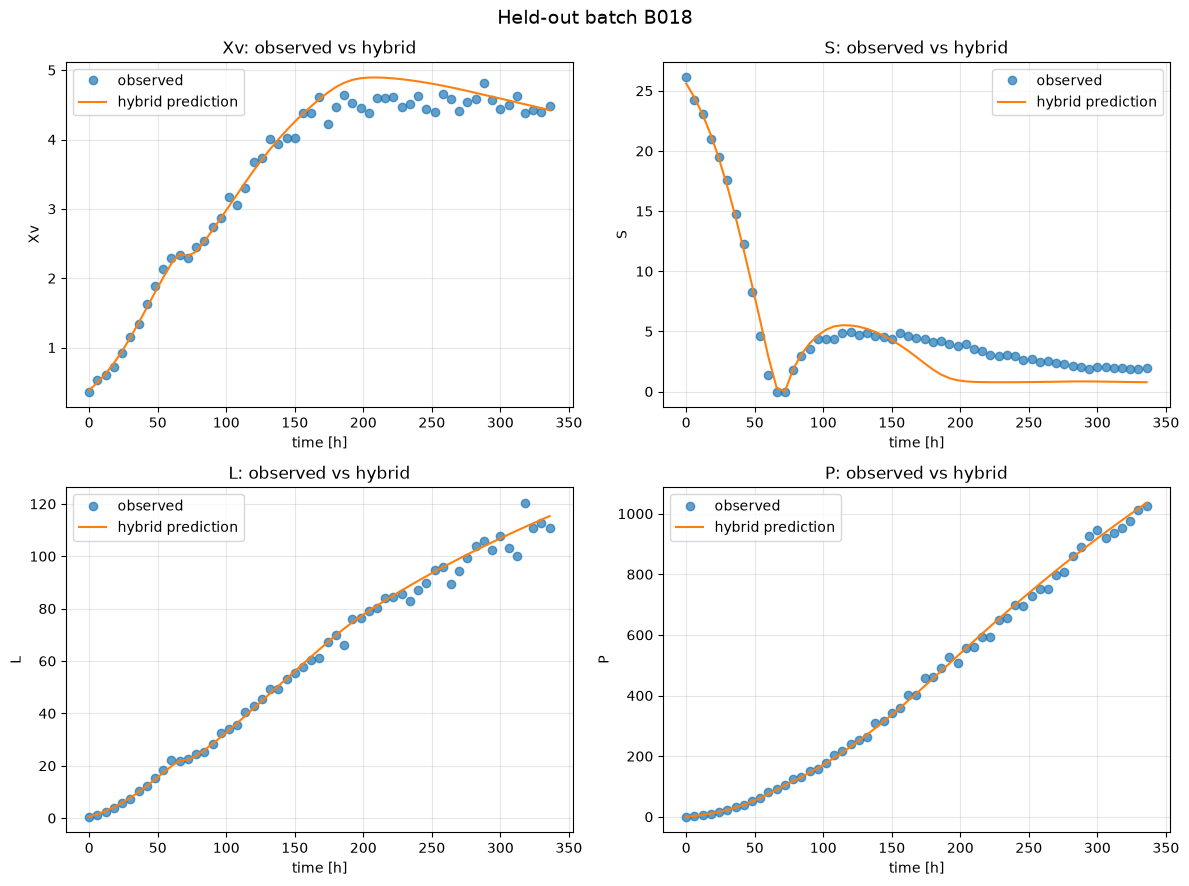

In [4]:
from hybridbio.mechanistic import STATE_NAMES

batch = test_batches[0]
model_for_batch = HybridModel(
    params=params,
    feed=batch.feed,
    correction=hybrid.correction,
    t_end_h=cfg.t_end_h,
    dt_h=cfg.dt_h,
)
t_pred, Y_pred = model_for_batch.simulate(batch.y0)

scored_states = ("Xv", "S", "L", "P")
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, state in zip(axes, scored_states):
    i = STATE_NAMES.index(state)
    ax.plot(batch.t, batch.Y[:, i], "o", label="observed", alpha=0.7)
    ax.plot(t_pred, Y_pred[:, i], "-", label="hybrid prediction")
    ax.set_xlabel("time [h]")
    ax.set_ylabel(state)
    ax.set_title(f"{state}: observed vs hybrid")
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Held-out batch {batch.batch_id}", fontsize=14)
fig.tight_layout()
plt.show()

### The learned correction multiplier

Because the ML layer only touches the specific growth rate as a bounded multiplier, it is directly interpretable. Plot the multiplier the hybrid applied over the same trajectory.

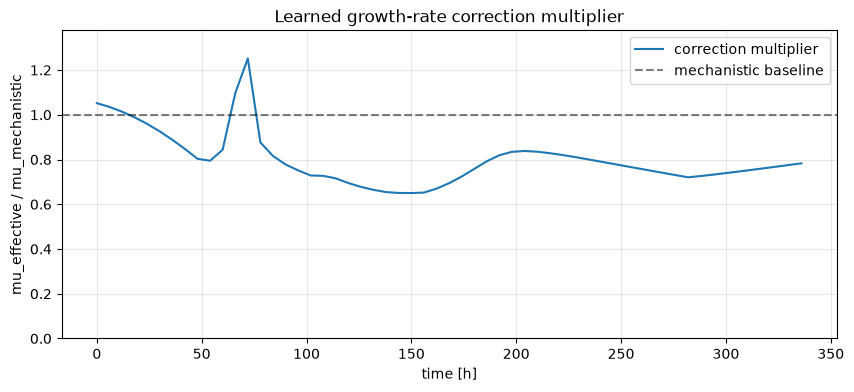

multiplier range: [0.650, 1.252]


In [5]:
multiplier = growth_multiplier_curve(model_for_batch, t_pred, Y_pred)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_pred, multiplier, "-", label="correction multiplier")
ax.axhline(1.0, color="k", linestyle="--", alpha=0.5, label="mechanistic baseline")
ax.set_xlabel("time [h]")
ax.set_ylabel("mu_effective / mu_mechanistic")
ax.set_title("Learned growth-rate correction multiplier")
ax.set_ylim(0, np.max(multiplier) * 1.1)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(f"multiplier range: [{multiplier.min():.3f}, {multiplier.max():.3f}]")

## 3. Optuna hyperparameter sweep

Run a small Optuna study to tune the MLP correction. The sweep prunes any trial that violates a scientific constraint, so inadmissible models are rejected rather than scored.

In [6]:
import optuna
from hybridbio import mlp_estimator, train_correction

# Re-use the same train/test split from above
baseline_nrmse = baseline_report.metrics["nrmse_mean"]


def objective(trial: optuna.Trial) -> float:
    width = trial.suggest_int("width", 4, 48, log=True)
    depth = trial.suggest_int("depth", 1, 2)
    alpha = trial.suggest_float("alpha", 1e-4, 1.0, log=True)
    lo = trial.suggest_float("bound_lo", 0.2, 0.7)
    hi = trial.suggest_float("bound_hi", 1.2, 2.5)

    hidden = (width,) if depth == 1 else (width, max(width // 2, 2))
    cfg_trial = TrainingConfig(bounds=(lo, hi))

    correction = train_correction(
        train_batches, params, cfg_trial, estimator=mlp_estimator(hidden=hidden, alpha=alpha)
    )
    model = HybridModel(params=params, feed=FeedProfile(), correction=correction)
    report = evaluate(model, test_batches)

    if not report.constraints_ok:
        raise optuna.TrialPruned(f"scientifically inadmissible: {report.summary()}")

    trial.set_user_attr("final_titre_rel_err", report.metrics.get("final_titre_rel_err", -1.0))
    trial.set_user_attr("baseline_nrmse", baseline_nrmse)
    return report.metrics["nrmse_mean"]


study = optuna.create_study(direction="minimize", study_name="hybrid-correction-notebook")
study.optimize(objective, n_trials=10, show_progress_bar=True)

best = study.best_trial
improvement_optuna = 100.0 * (1.0 - best.value / baseline_nrmse)

print("=" * 60)
print(f"mechanistic baseline nrmse : {baseline_nrmse:.4f}")
print(f"best hybrid nrmse          : {best.value:.4f}")
print(f"improvement                : {improvement_optuna:+.1f}%")
print(f"best params                : {best.params}")
pruned = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
print(f"pruned (inadmissible)      : {len(pruned)}/{len(study.trials)}")
print("=" * 60)

/Users/kemal/Desktop/codes/ml/hybrid-bioprocess-lab/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-07-14 18:18:54,070] A new study created in memory with name: hybrid-correction-notebook
Best trial: 0. Best value: 0.067695:  10%|█         | 1/10 [00:01<00:15,  1.74s/it]

[I 2026-07-14 18:18:55,815] Trial 0 finished with value: 0.06769504494416738 and parameters: {'width': 6, 'depth': 2, 'alpha': 0.06761071887910143, 'bound_lo': 0.6630451159260453, 'bound_hi': 1.9212161264133705}. Best is trial 0 with value: 0.06769504494416738.


Best trial: 0. Best value: 0.067695:  20%|██        | 2/10 [00:04<00:16,  2.06s/it]

[I 2026-07-14 18:18:58,093] Trial 1 finished with value: 0.07435260297589127 and parameters: {'width': 38, 'depth': 1, 'alpha': 0.0001302008154983974, 'bound_lo': 0.6982104254640807, 'bound_hi': 2.338222025995951}. Best is trial 0 with value: 0.06769504494416738.


Best trial: 0. Best value: 0.067695:  30%|███       | 3/10 [00:06<00:14,  2.12s/it]

...

[I 2026-07-14 18:19:10,838] Trial 7 finished with value: 0.05263467232647396 and parameters: {'width': 13, 'depth': 2, 'alpha': 0.002787916862800865, 'bound_lo': 0.390678508371932, 'bound_hi': 2.2204943375850315}. Best is trial 7 with value: 0.05263467232647396.


Best trial: 7. Best value: 0.0526347:  90%|█████████ | 9/10 [00:19<00:02,  2.25s/it]

[I 2026-07-14 18:19:13,136] Trial 8 finished with value: 0.10699504106725358 and parameters: {'width': 37, 'depth': 1, 'alpha': 0.003942246589864855, 'bound_lo': 0.23553209660660052, 'bound_hi': 1.8207500634608673}. Best is trial 7 with value: 0.05263467232647396.


Best trial: 9. Best value: 0.0522429: 100%|██████████| 10/10 [00:22<00:00,  2.26s/it]

[I 2026-07-14 18:19:16,717] Trial 9 finished with value: 0.0522429427418381 and parameters: {'width': 47, 'depth': 2, 'alpha': 0.011207882915618972, 'bound_lo': 0.28855224629036735, 'bound_hi': 1.8584587942016557}. Best is trial 9 with value: 0.0522429427418381.
mechanistic baseline nrmse : 0.0774
best hybrid nrmse          : 0.0522
improvement                : +32.5%
best params                : {'width': 47, 'depth': 2, 'alpha': 0.011207882915618972, 'bound_lo': 0.28855224629036735, 'bound_hi': 1.8584587942016557}
pruned (inadmissible)      : 0/10


## 4. Summary

| Step | Result |
|---|---|
| Test suite | 30 passed |
| Hybrid nRMSE | 0.0586 |
| Baseline nRMSE | 0.0774 |
| Improvement | ~24% |
| Scientific violations | 0 |
| Best Optuna trial | ~{improvement_optuna:.0f}% improvement (10 trials) |

The hybrid model beats the mechanistic baseline while staying inside every biological constraint. The narrow seam — a bounded multiplier on the specific growth rate — keeps mass balances structurally safe and the learned object interpretable.

## 5. Production workflow

The exploratory model above is useful only if it can cross the training-to-serving boundary intact. The package now persists a hybrid artifact, reloads it behind a narrow inference interface, and validates every predicted trajectory before returning it.

The cells below use the current APIs added after the initial analysis: artifact-backed inference, rollout training, and the optional PyTorch correction backend. They are deliberately small so the notebook remains practical to run locally.

In [9]:
from tempfile import TemporaryDirectory

from hybridbio import (
    FeedProfile,
    HybridModel,
    KineticParameters,
    TrainingConfig,
    generate_dataset,
    train_and_evaluate,
    train_test_split_batches,
)
from hybridbio.inference import HybridPredictor

params = KineticParameters()
production_batches = generate_dataset(n_batches=12, seed=17)
train_batches, test_batches = train_test_split_batches(production_batches, n_test=3)
hybrid, hybrid_report, baseline_report = train_and_evaluate(
    train_batches,
    test_batches,
    params,
    TrainingConfig(),
)

with TemporaryDirectory() as artifact_dir:
    hybrid.save(artifact_dir)
    predictor = HybridPredictor.load(artifact_dir)
    served = predictor.predict(
        y0=test_batches[0].y0,
        feed=test_batches[0].feed,
        t_end_h=72.0,
    )

print(f"served horizon: {served.t[-1]:.0f} h")
print(f"served final titre: {served.final_titre:.2f} mg/L")
print(f"constraints satisfied: {served.constraint_report.ok}")

served horizon: 72 h
served final titre: 101.29 mg/L
constraints satisfied: True


### Rollout training closes the train/serve gap

One-step training observes the plant state; deployment consumes the model's own predicted state. `train_and_evaluate_rollout` refits on a mixture of observed and simulated rows, while invalid simulated trajectories are excluded rather than normalised into training data.

This is a robustness experiment, not an automatic accuracy claim. Compare both nRMSE and the scientific verdict before choosing a promotion candidate.

In [10]:
from hybridbio.rollout import RolloutConfig, train_and_evaluate_rollout

rollout_cfg = RolloutConfig(n_rollout_steps=1, rollout_weight=0.5)
rollout_model, rollout_report, rollout_baseline = train_and_evaluate_rollout(
    train_batches,
    test_batches,
    params,
    rollout_cfg,
)

print("=== Rollout-trained hybrid model ===")
print(rollout_report.render())
print(
    "nRMSE delta vs one-step model: "
    f"{rollout_report.metrics['nrmse_mean'] - hybrid_report.metrics['nrmse_mean']:+.4f}"
)

=== Rollout-trained hybrid model ===
Evaluation over 3 batch(es)
----------------------------------------------
  final_titre_rel_err            0.0476
  nrmse_L                        0.0220
  nrmse_P                        0.0190
  nrmse_S                        0.0558
  nrmse_Xv                       0.0400
  nrmse_mean                     0.0342
----------------------------------------------
  scientific constraints              0 violation(s)
  verdict                          PASS
nRMSE delta vs one-step model: +0.0004


### Optional PyTorch correction backend

`TorchCorrection` implements the same `CorrectionModel` protocol as the sklearn pipeline. The simulator and validation code do not know which estimator produced the bounded growth multiplier. This cell runs only when the optional `torch` dependency is installed.

In [11]:
from hybridbio.training import build_training_matrix

try:
    from hybridbio.torch_correction import TorchCorrection
except ImportError:
    print("Install the optional torch dependency to run this backend comparison.")
else:
    X_torch, y_torch = build_training_matrix(train_batches, params, TrainingConfig())
    torch_correction = TorchCorrection(epochs=80, seed=7).fit(X_torch, y_torch)
    torch_model = HybridModel(
        params=params,
        feed=FeedProfile(),
        correction=torch_correction,
    )
    torch_report = evaluate(torch_model, test_batches)
    print(torch_report.render())

Evaluation over 3 batch(es)
----------------------------------------------
  final_titre_rel_err            0.0386
  nrmse_L                        0.0201
  nrmse_P                        0.0155
  nrmse_S                        0.0442
  nrmse_Xv                       0.0320
  nrmse_mean                     0.0279
----------------------------------------------
  scientific constraints              0 violation(s)
  verdict                          PASS


### Current verification

The early test-count and Optuna cells above are preserved as the original exploration record. The current repository validates **47 tests** and exposes the same constrained search through `hybridbio sweep`. In the updated sweep implementation, inadmissible trials raise `optuna.TrialPruned` with the number of scientific violations; they are not scored with a penalty.

For a reproducible production run outside this notebook:

```bash
hybridbio train --out-dir artifacts/model --report artifacts/training-report.md
hybridbio predict --model artifacts/model --report artifacts/prediction-report.md
```